# Jensen Alpha Momentum — 6M — Winner Drift

One signal, one formation horizon and one maintenance method. The experiment contains nine cells: rebalance every 1, 3 or 6 months × target N=12, 24 or 50.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'src'))
from momentum_india.notebook_views import ResearchNotebook

research = ResearchNotebook('jensen_alpha', '6M', 'winner_drift')

## 1. Signal and portfolio rule

Daily stock excess return = alpha + beta × daily Nifty 50 excess return + residual. Both excess returns subtract the continuous liquid-fund daily return. OLS alpha is the ranking score over the fixed formation window; this is a trailing signal, not the strategy's subsequently realized alpha.

Continuing holdings retain their naturally drifted weights, capped at 2/N at scheduled rebalances. Exits and entrants are paired in stable symbol order; an entrant receives min(exit weight, 1/N). Excess exit weight and cap trims are spread equally among continuing holdings with room below the cap. Unmatched entrants share existing cash up to 1/N each. Residual cash is retained. The cap is a scheduled target constraint, not a daily trim rule.

## 2. Universe → ranking → actual portfolio

The example uses the latest monthly N=24 signal and exposes the ranking inputs and actual target weights.

Symbol,Daily alpha,MDTV (INR)
NSE:UFBL-EQ,0.0132,"42,078,240.59"
NSE:YASHO-EQ,0.0106,"37,220,195.50"
NSE:HFCL-EQ,0.0096,"3,688,024,397.99"
NSE:CUPID-EQ,0.0095,"2,261,224,535.95"
NSE:DIACABS-EQ,0.0092,"490,913,783.79"
NSE:AEROFLEX-EQ,0.0090,"644,982,030.67"
NSE:CONFIPET-EQ,0.0084,"129,439,974.50"
NSE:GRWRHITECH-EQ,0.0084,"309,324,106.35"
NSE:SETL-EQ,0.0083,"42,154,727.49"
NSE:SUVEN-EQ,0.0082,"120,651,212.30"


Symbol,Leg,Actual weight,Current selection,Execution status,Daily alpha,MDTV (INR)
NSE:UFBL-EQ,long,1.0%,True,selected,0.0132,"42,078,240.59"
NSE:YASHO-EQ,long,1.6%,True,selected,0.0106,"37,220,195.50"
NSE:HFCL-EQ,long,0.6%,True,selected,0.0096,"3,688,024,397.99"
NSE:CUPID-EQ,long,0.7%,True,selected,0.0095,"2,261,224,535.95"
NSE:DIACABS-EQ,long,0.6%,True,selected,0.0092,"490,913,783.79"
NSE:AEROFLEX-EQ,long,1.3%,True,selected,0.0090,"644,982,030.67"
NSE:CONFIPET-EQ,long,0.5%,True,selected,0.0084,"129,439,974.50"
NSE:GRWRHITECH-EQ,long,0.6%,True,selected,0.0084,"309,324,106.35"
NSE:SETL-EQ,long,0.5%,True,selected,0.0083,"42,154,727.49"
NSE:SUVEN-EQ,long,0.4%,True,selected,0.0082,"120,651,212.30"


Symbol,Formation start,Start adjusted close,Signal close date,End adjusted close,Formation price return
NSE:UFBL-EQ,2026-01-30,181.20,2026-07-31,701.65,287.2%


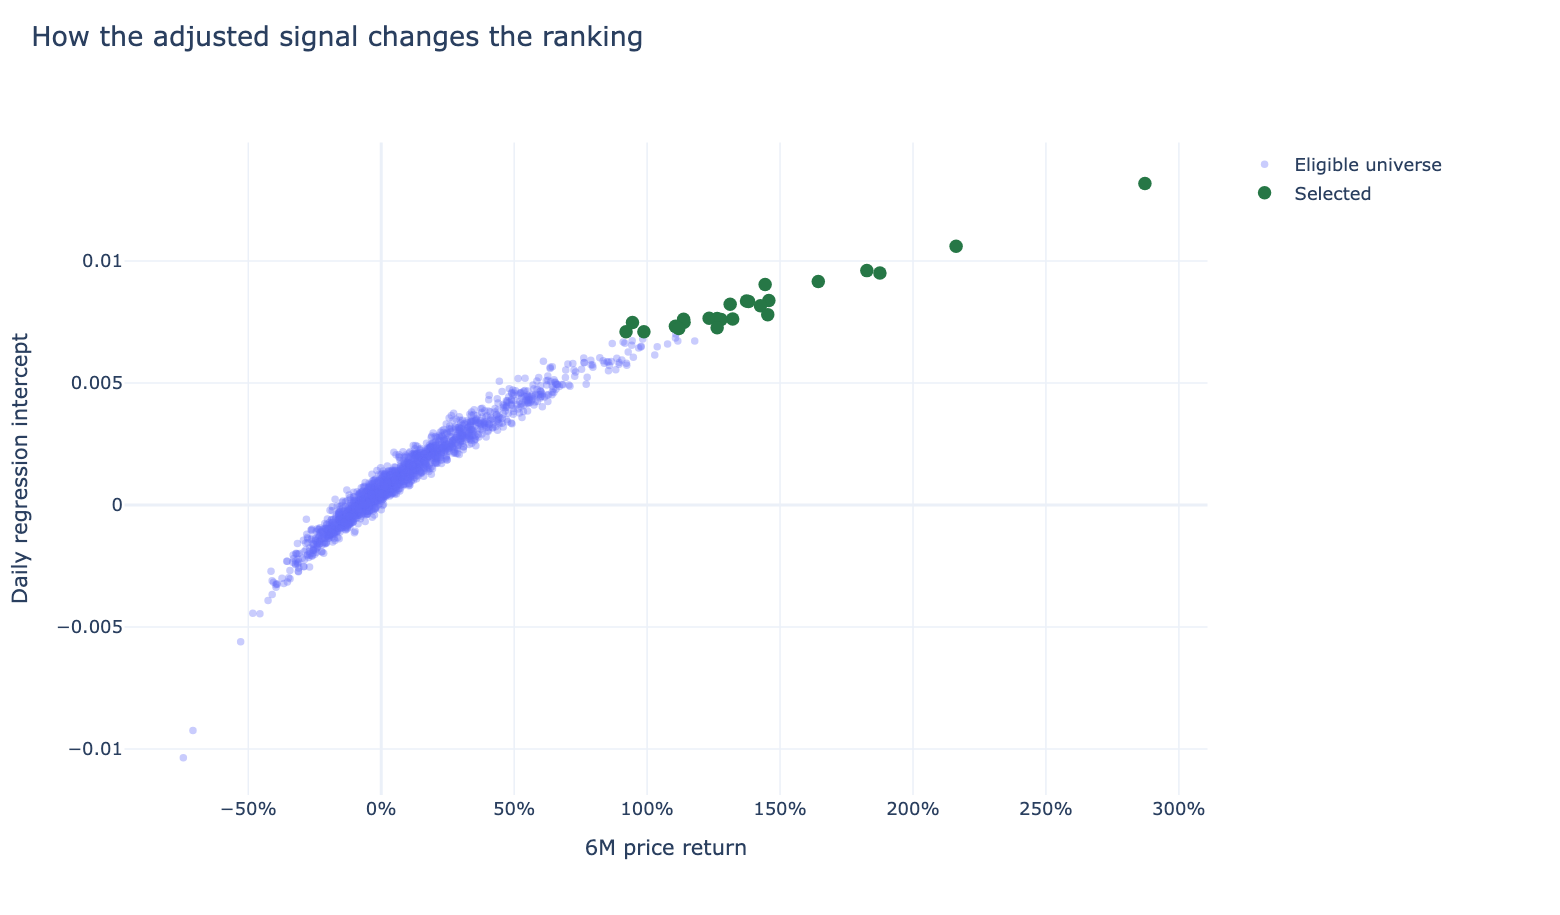

In [2]:
research.snapshot()

## 3. Return layers across all nine cells

Raw is before trading charges. After-cost gross/pre-tax deducts modeled trading charges. The long-only post-tax overlay additionally applies the annual equity-gains ledger. The academic reference instead compares raw and borrowing-adjusted layers.

In [3]:
research.layers_bridge()

Rebalance,First date,Last date,Sessions
1M,2007-05-03,2026-08-28,4771
3M,2007-07-02,2026-08-28,4729
6M,2007-07-02,2026-08-28,4729


Rebalance,N,Raw,After costs,Post-tax overlay
1M,12,9.1%,8.5%,7.6%
1M,24,12.3%,11.8%,10.6%
1M,50,13.6%,13.0%,11.7%
3M,12,4.5%,4.2%,3.8%
3M,24,11.1%,10.9%,9.8%
3M,50,12.5%,12.1%,10.7%
6M,12,5.5%,5.3%,4.6%
6M,24,9.6%,9.4%,8.4%
6M,50,9.0%,8.8%,8.1%


## 4. Risk-adjusted results

Sharpe uses daily excess returns relative to the liquid fund. VaR and expected shortfall are historical monthly 95% loss measures. Partial first/last months are included. Time below prior peak counts days awaiting a new all-time high—not losing days. The initial invested capital is included as the first peak.

In [4]:
research.risk_grid()

Rebalance,N,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,12,7.6%,0.114,-82.6%,8.2%
1M,24,10.6%,0.276,-80.6%,8.1%
1M,50,11.7%,0.343,-78.5%,8.4%
3M,12,3.8%,-0.100,-86.4%,7.2%
3M,24,9.8%,0.233,-80.2%,8.8%
3M,50,10.7%,0.274,-80.7%,9.7%
6M,12,4.6%,-0.058,-77.8%,9.3%
6M,24,8.4%,0.155,-73.1%,7.7%
6M,50,8.1%,0.133,-75.6%,7.4%


Rebalance,N,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,12,16.4%,94.6%,1944
1M,24,15.4%,92.7%,1654
1M,50,14.6%,90.4%,1598
3M,12,17.4%,98.7%,4545
3M,24,15.7%,93.2%,1734
3M,50,17.0%,94.2%,1687
6M,12,16.7%,97.5%,1948
6M,24,15.1%,94.2%,1939
6M,50,14.8%,93.4%,2274


### CAGR

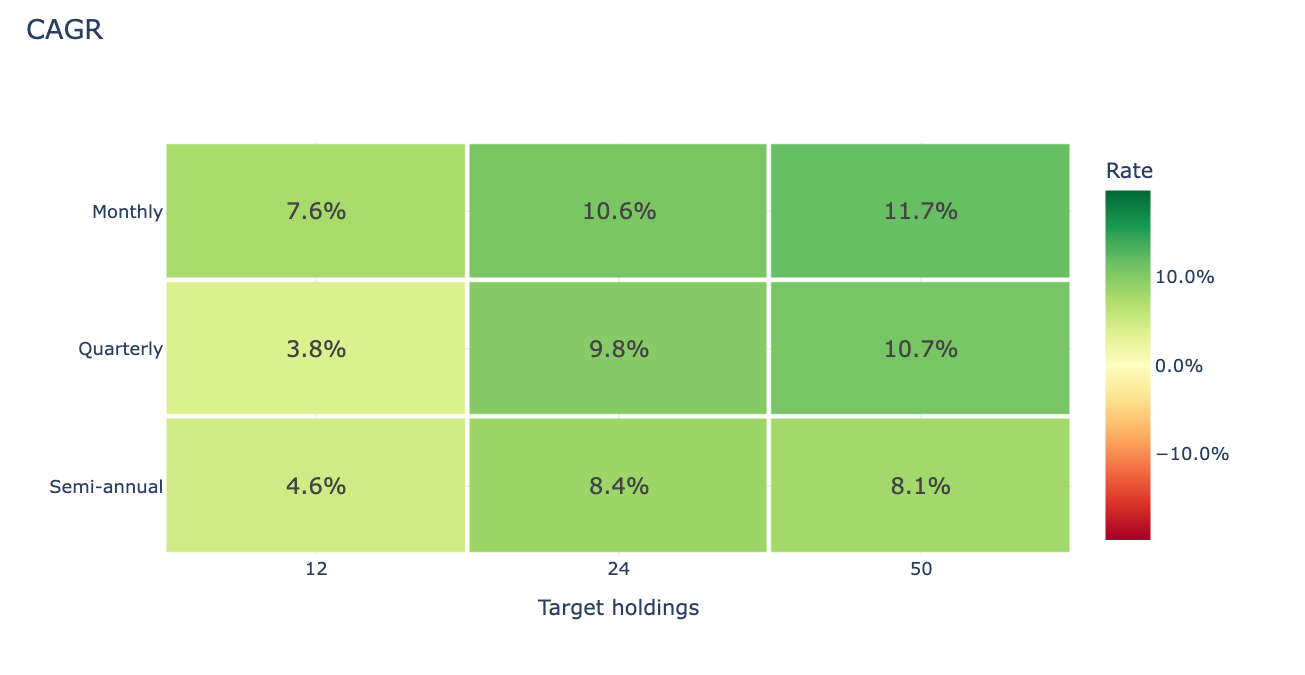

In [5]:
research.heatmap('cagr')

### Sharpe ratio

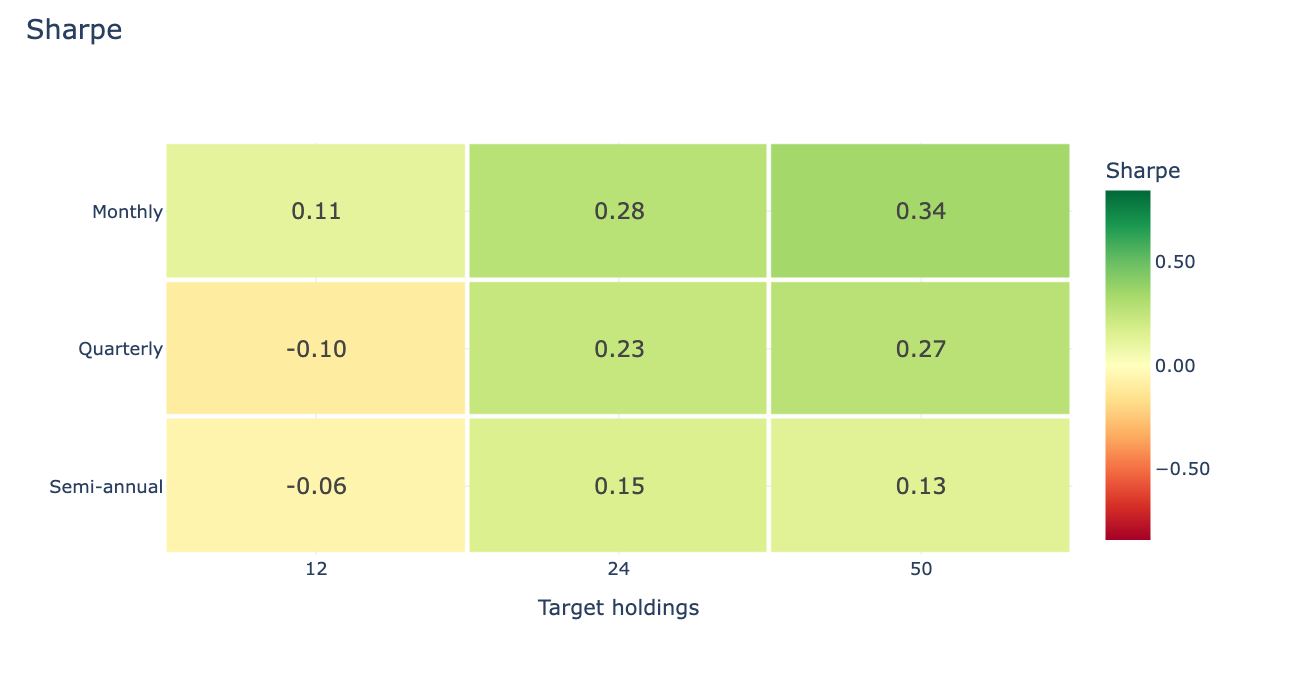

In [6]:
research.heatmap('sharpe')

### Maximum drawdown

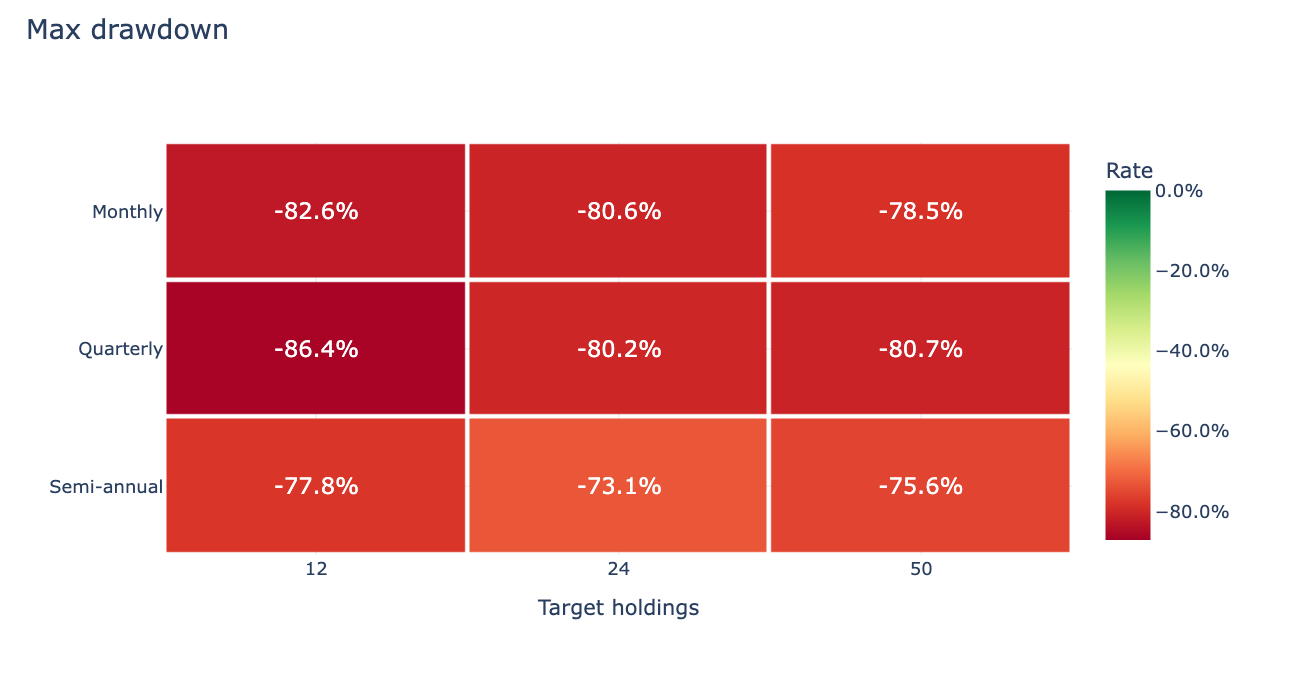

In [7]:
research.heatmap('maximum_drawdown')

### Monthly 95% VaR

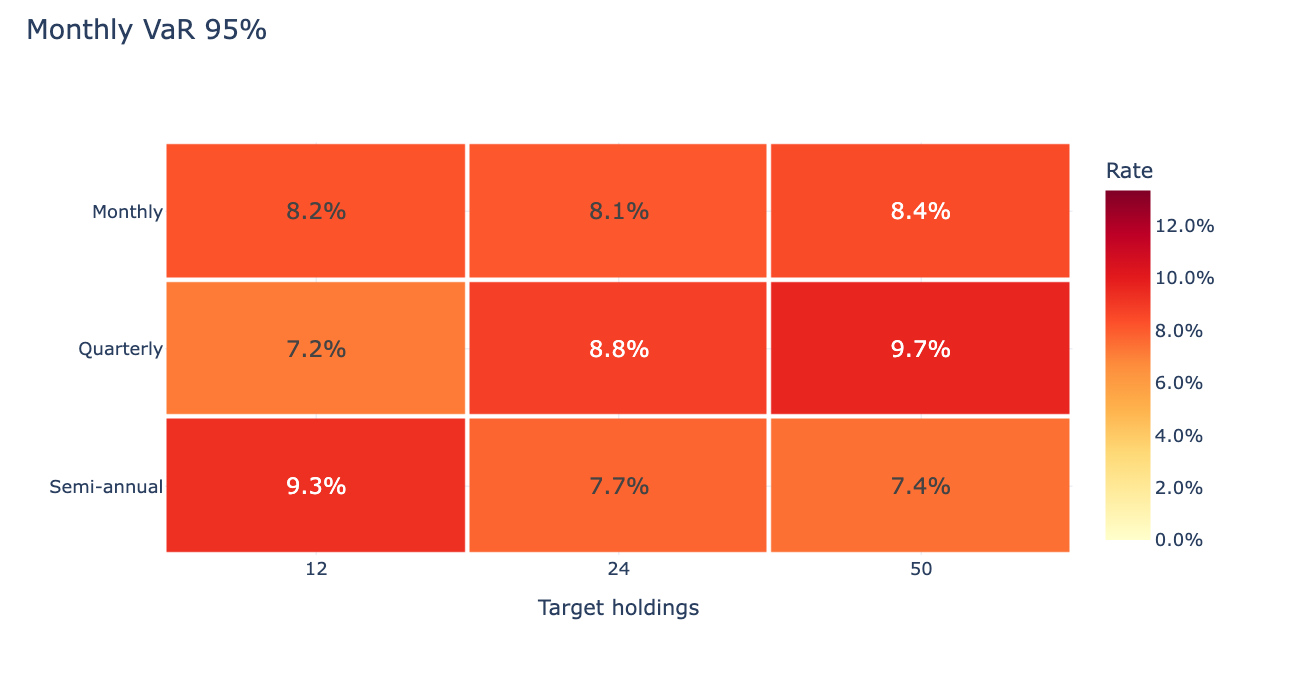

In [8]:
research.heatmap('monthly_var_95')

## 5. Equity paths and matched risks

Each chart fixes breadth and compares rebalance frequencies. Final-layer curves and the price benchmark start visible; other return layers remain in the selectable legend. Logarithmic axes make early and late periods comparable; the bottom range slider preserves the full history. Curves display weekly observations for readability, while every statistic uses the complete daily series.

### N=12

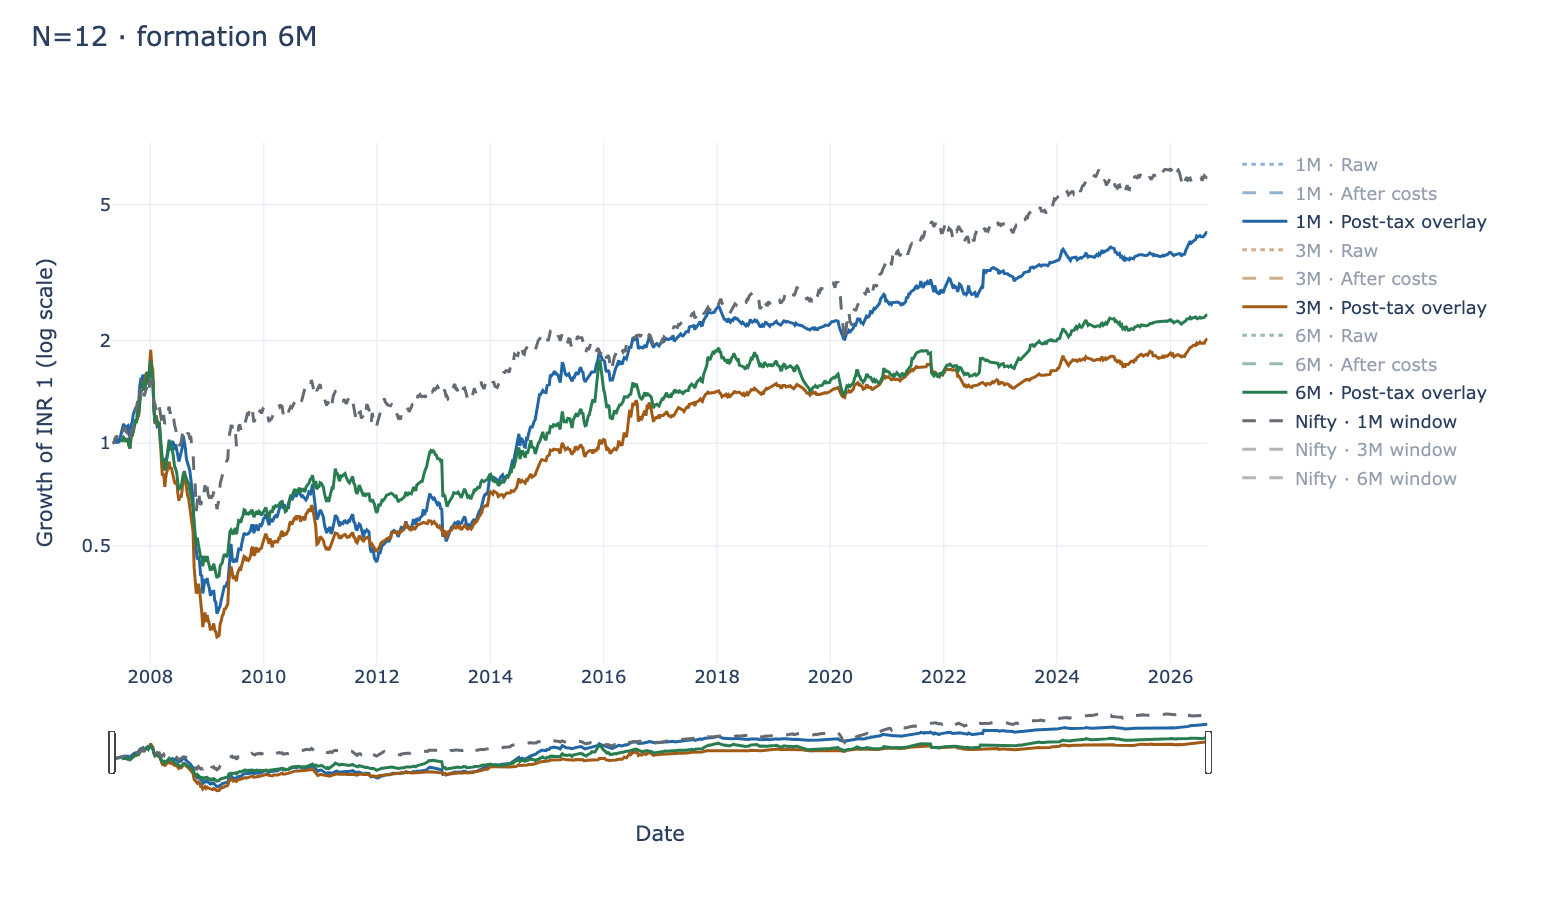

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Raw,9.1%,0.193,-81.9%,8.3%
1M,After costs,8.5%,0.161,-82.3%,8.2%
1M,Post-tax overlay,7.6%,0.114,-82.6%,8.2%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Raw,4.5%,-0.060,-85.0%,7.1%
3M,After costs,4.2%,-0.075,-85.1%,7.2%
3M,Post-tax overlay,3.8%,-0.100,-86.4%,7.2%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%
6M,Raw,5.5%,-0.011,-75.5%,9.1%
6M,After costs,5.3%,-0.024,-75.8%,9.3%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Raw,16.2%,93.4%,1784
1M,After costs,16.2%,93.8%,1940
3M,Raw,16.8%,97.7%,3957
3M,After costs,16.9%,98.0%,3966
6M,Raw,16.0%,96.7%,1942
6M,After costs,16.2%,97.0%,1943
1M,Post-tax overlay,16.4%,94.6%,1944
3M,Post-tax overlay,17.4%,98.7%,4545
6M,Post-tax overlay,16.7%,97.5%,1948
1M,Nifty 50 price,13.1%,92.4%,1520


In [9]:
research.equity(12)

### N=24

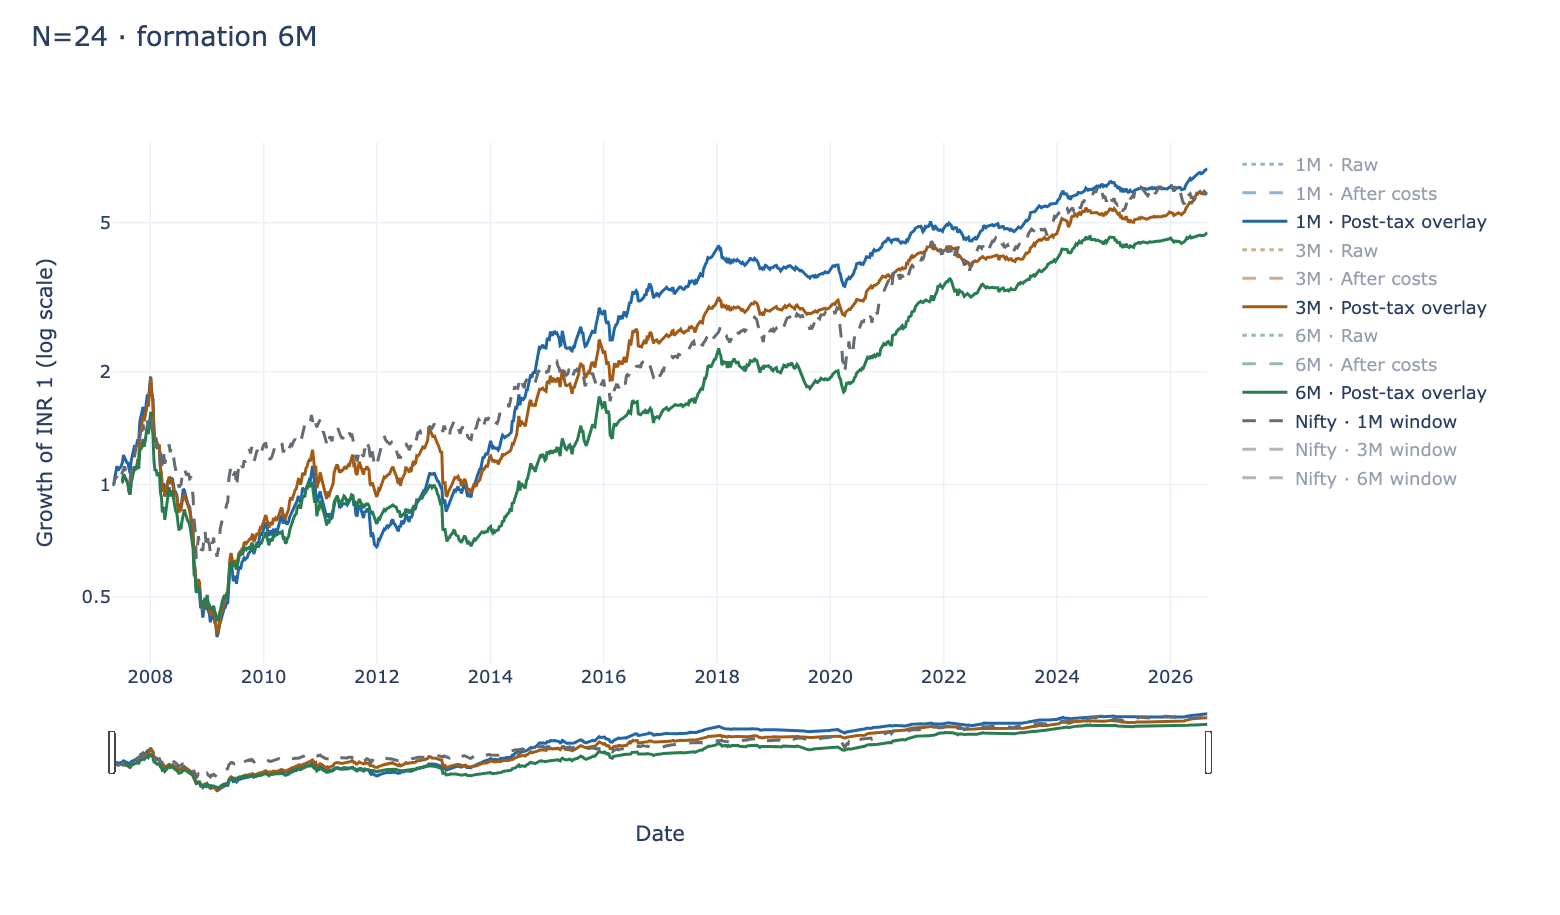

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Raw,12.3%,0.374,-79.5%,7.7%
1M,After costs,11.8%,0.343,-80.0%,7.9%
1M,Post-tax overlay,10.6%,0.276,-80.6%,8.1%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Raw,11.1%,0.305,-79.0%,8.6%
3M,After costs,10.9%,0.296,-79.2%,8.8%
3M,Post-tax overlay,9.8%,0.233,-80.2%,8.8%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%
6M,Raw,9.6%,0.226,-71.0%,7.5%
6M,After costs,9.4%,0.213,-71.3%,7.6%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Raw,15.0%,91.1%,1632
1M,After costs,15.1%,91.7%,1647
3M,Raw,15.3%,91.9%,1687
3M,After costs,15.4%,92.3%,1720
6M,Raw,14.6%,93.0%,1918
6M,After costs,14.7%,93.1%,1932
1M,Post-tax overlay,15.4%,92.7%,1654
3M,Post-tax overlay,15.7%,93.2%,1734
6M,Post-tax overlay,15.1%,94.2%,1939
1M,Nifty 50 price,13.1%,92.4%,1520


In [10]:
research.equity(24)

### N=50

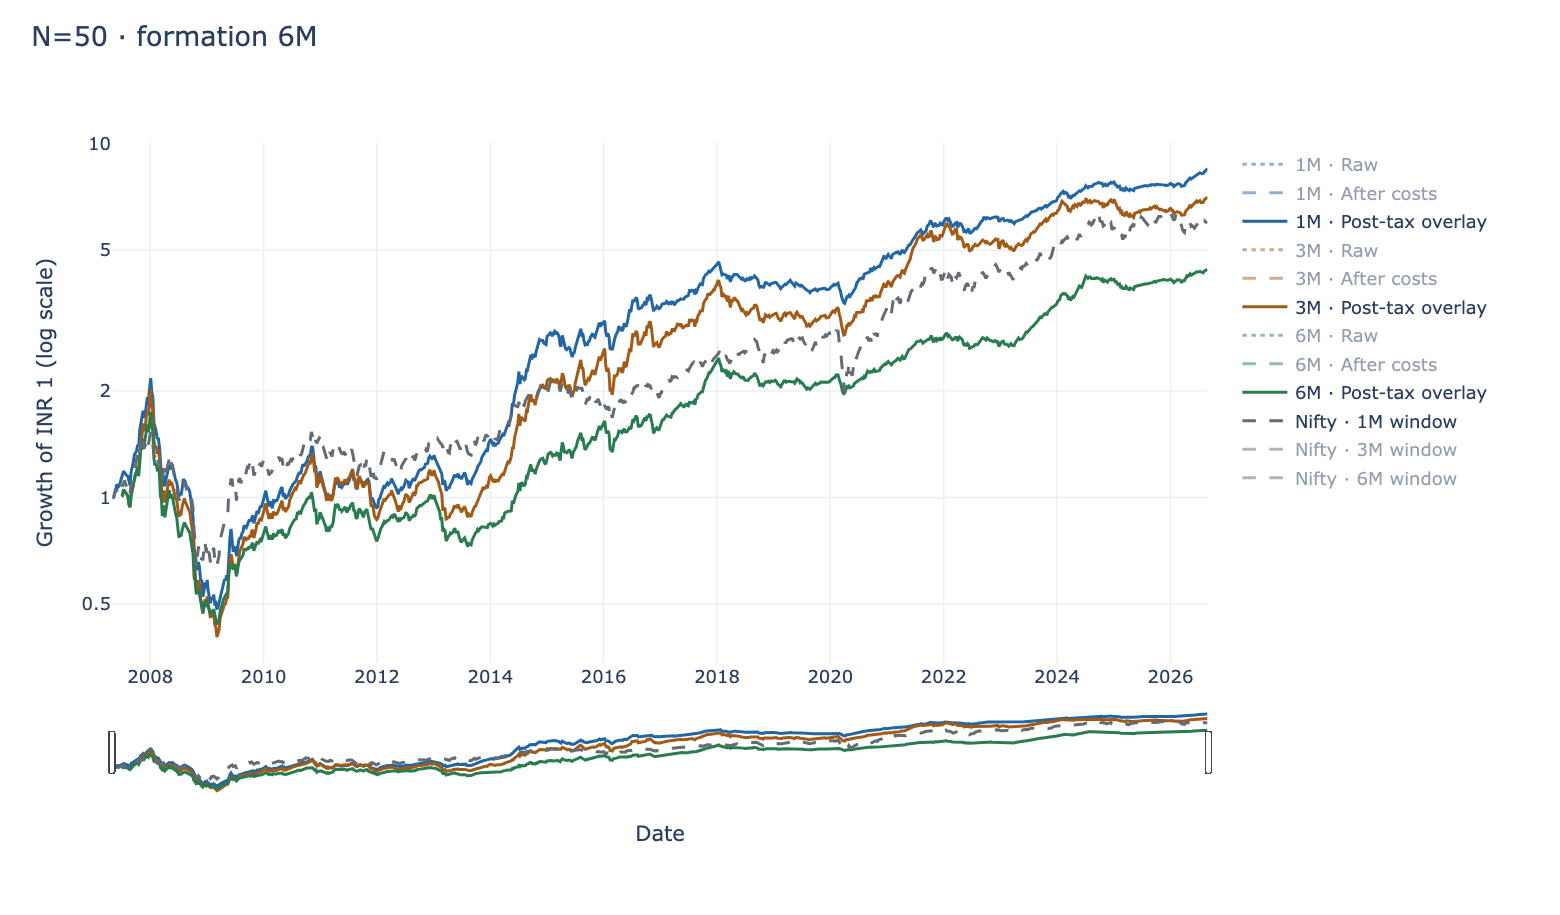

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Raw,13.6%,0.452,-77.5%,8.0%
1M,After costs,13.0%,0.416,-77.9%,8.2%
1M,Post-tax overlay,11.7%,0.343,-78.5%,8.4%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Raw,12.5%,0.364,-79.6%,9.5%
3M,After costs,12.1%,0.343,-79.8%,9.7%
3M,Post-tax overlay,10.7%,0.274,-80.7%,9.7%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%
6M,Raw,9.0%,0.194,-73.9%,7.3%
6M,After costs,8.8%,0.178,-74.2%,7.4%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Raw,14.2%,88.8%,1583
1M,After costs,14.3%,89.5%,1597
3M,Raw,16.6%,92.7%,1645
3M,After costs,16.7%,93.0%,1653
6M,Raw,14.3%,92.5%,1966
6M,After costs,14.4%,92.8%,2092
1M,Post-tax overlay,14.6%,90.4%,1598
3M,Post-tax overlay,17.0%,94.2%,1687
6M,Post-tax overlay,14.8%,93.4%,2274
1M,Nifty 50 price,13.1%,92.4%,1520


In [11]:
research.equity(50)

## 6. Recovery burden

The longest underwater episode is shown by its peak, trough and recovery dates. Unrecovered episodes remain explicitly open.

In [12]:
research.recovery()

Series,Peak,Trough,Recovery,Sessions,Calendar days,Episode loss
1M,2008-01-07,2009-03-09,2014-09-22,1654,2449,-80.6%
3M,2008-01-07,2009-03-09,2015-01-22,1734,2571,-80.2%
6M,2008-01-07,2009-03-09,2015-11-23,1939,2876,-73.1%
Nifty · 1M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%
Nifty · 3M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%
Nifty · 6M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%


## 7. Portfolio behavior

Scheduled turnover is (buy value + sell value)/(2 × pre-trade equity). Retention compares successive scheduled target name sets. Cash and total charges include the intervening daily path.

In [13]:
research.behavior()

Rebalance,N,Mean names at rebalance,Mean cash weight,Scheduled name retention
1M,12,21.85,30.4%,71.0%
1M,24,38.05,32.9%,69.2%
1M,50,74.04,30.7%,70.3%
3M,12,17.86,51.5%,43.6%
3M,24,37.73,35.8%,48.6%
3M,50,69.70,21.3%,47.4%
6M,12,18.87,31.9%,36.2%
6M,24,34.03,42.6%,30.5%
6M,50,70.72,35.1%,32.5%


Rebalance,N,Mean scheduled turnover,All trading charges (INR),Days with stop sales
1M,12,19.3%,"1,812,385.70",0
1M,24,19.7%,"2,849,719.60",0
1M,50,19.2%,"3,402,501.53",0
3M,12,26.0%,"573,174.52",0
3M,24,33.6%,"1,427,428.17",0
3M,50,41.5%,"2,383,249.25",0
6M,12,40.9%,"545,524.92",0
6M,24,41.0%,"733,686.22",0
6M,50,42.7%,"782,302.20",0


## 8. Market-state attribution

This is an observation, not an extra strategy filter. Prior-close Nifty 50 versus SMA(200) defines up/down; 63-session volatility versus its expanding historical median defines high/low volatility. The representative monthly N=24 path is shown with shaded states.

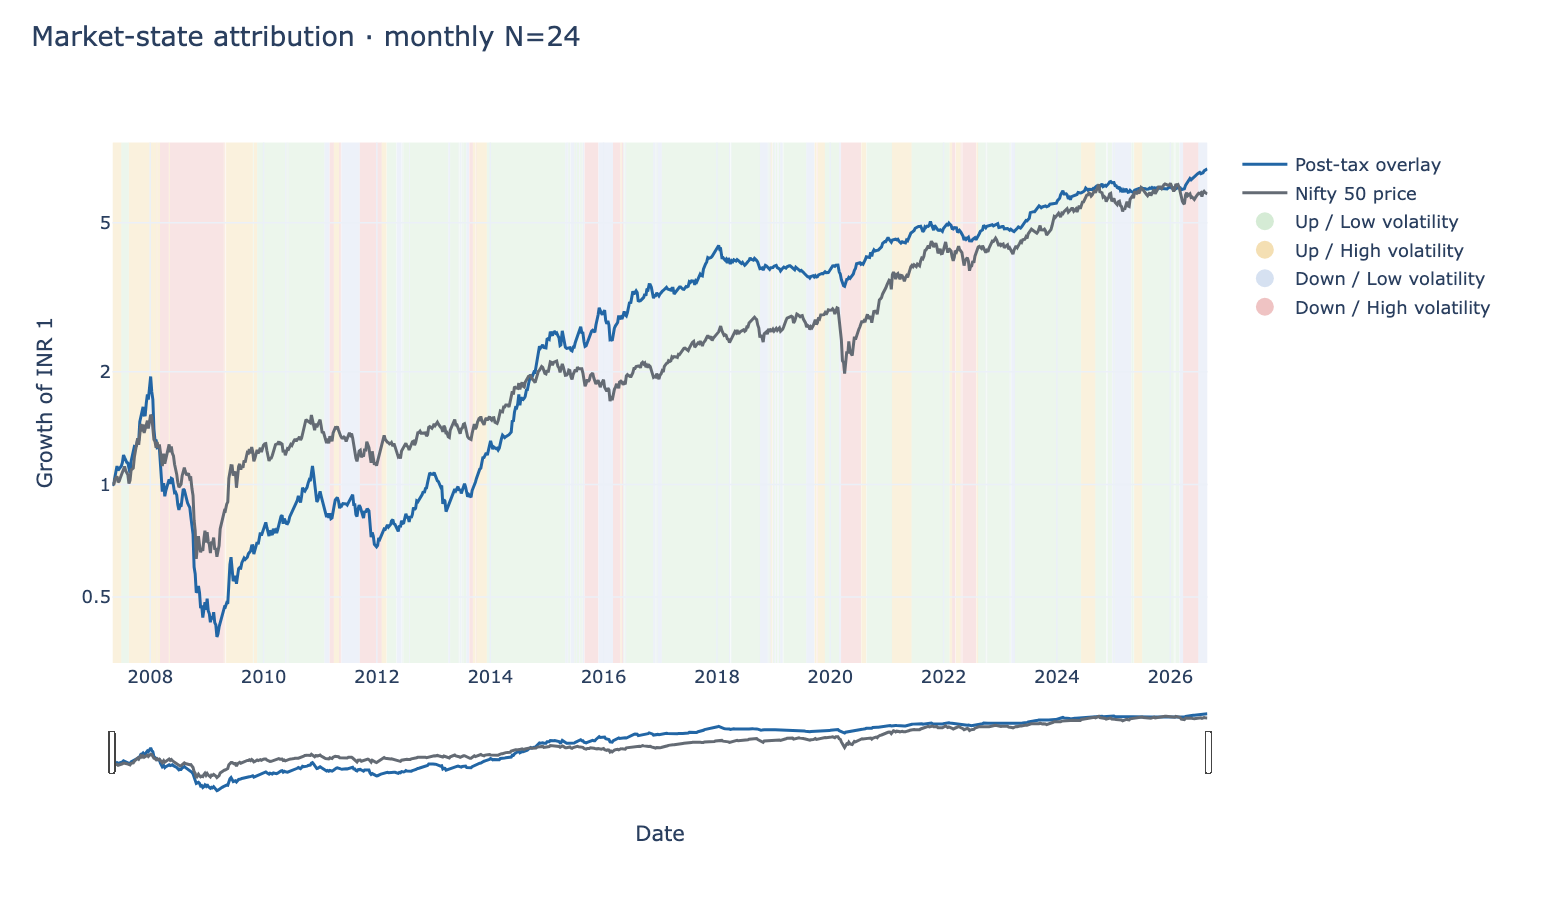

Market state,Sessions,Mean daily return,Daily volatility,Positive days
Down / High volatility,748,-0.06%,1.46%,55.61%
Down / Low volatility,609,-0.02%,0.90%,51.40%
Up / High volatility,720,0.15%,1.31%,60.00%
Up / Low volatility,2694,0.06%,0.83%,57.31%


In [14]:
research.regimes()

## 9. Complete portfolio and trade evidence

Risk metrics are included in the repository. Complete portfolio and trade CSVs belong to the local full-data research run.

In [15]:
research.portfolio_exports()

Rebalance,N,First rebalance,Last rebalance,Rebalance dates,Holding rows
1M,12,2007-05-03,2026-08-03,232,5070
1M,24,2007-05-03,2026-08-03,232,8827
1M,50,2007-05-03,2026-08-03,232,17177
3M,12,2007-07-02,2026-07-01,77,1375
3M,24,2007-07-02,2026-07-01,77,2905
3M,50,2007-07-02,2026-07-01,77,5367
6M,12,2007-07-02,2026-07-01,39,736
6M,24,2007-07-02,2026-07-01,39,1327
6M,50,2007-07-02,2026-07-01,39,2758


## Findings

In [16]:
research.conclusion()

Matched reference: [Raw Momentum — 6M — Winner Drift](03_raw_momentum_6m_winner_drift.ipynb). The comparison holds formation, maintenance, frequency and N fixed.